## Bài 1: Titanic Dataset

Sử dụng lại bộ dữ liệu **Titanic** trong bài tập về nhà trước.

### Yêu cầu

1. Sử dụng **Logistic Regression** để dự đoán hành khách sống sót hay không.
2. Sử dụng cùng cách chia dữ liệu train/test như bài tập trước nếu có thể.
3. Đánh giá kết quả của mô hình Logistic Regression.
4. So sánh kết quả của **Logistic Regression** với kết quả của **Linear Regression** trong bài tập trước.

### Nội dung so sánh

Có thể so sánh dựa trên các chỉ số:

- Accuracy
- Precision
- Recall
- F1-score
- Confusion Matrix

Đưa ra nhận xét về mô hình phù hợp hơn đối với bài toán phân loại hành khách sống sót.

## 1. Import thư viện

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import(
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

pd.set_option("display.max_columns", None)
sns.set_theme(style = "whitegrid")
plt.rcParams["figure.dpi"] = 100

RANDOM_STATE = 42
print("Đã import xong thư viện.")


Đã import xong thư viện.


## 2. Tải dữ liệu Titanic

>Giống Buổi 5: ưu tiên tải qua `seaborn`; nếu không tải được (ví dụ máy không có Internet), sẽ tự động chuyển sang tải từ URL dự phòng, sau đó lưu lại một bản CSV cục bộ (`data_path`) để lần chạy sau không cần tải lại.


In [2]:
DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok = True)
data_path = DATA_DIR / "titanic_raw.csv"   # nơi lưu / đọc bản dữ liệu cục bộ

if data_path.exists():
    df = pd.read_csv(data_path)
    print(f"Đã đọc dữ liệu từ file cục bộ: {data_path}")
else:
    try:
        df = sns.load_dataset("titanic")
        print("Đã tải từ seaborn.")
    except Exception:
        url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
        df = pd.read_csv(url)
        df.columns = [c.lower() for c in df.columns]
        print("Đã tải từ URL dự phòng.")

    df.to_csv(data_path, index = False)
    print(f"Đã lưu bản cục bộ tại: {data_path}")

print("Kích thước dữ liệu gốc:", df.shape)
df.head()

Đã đọc dữ liệu từ file cục bộ: data\titanic_raw.csv
Kích thước dữ liệu gốc: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## 3. Tiền xử lý giống Buổi 5

### 3.1. Bỏ các cột rò rỉ nhãn / dư thừa

> Giữ nguyên đúng danh sách cột đã loại bỏ ở Buổi 5: `alive` (chính là `survived` viết bằng chữ — rò rỉ target trực tiếp), `deck` (thiếu ~77%), `embark_town` (trùng `embarked`), `adult_male`, `who`, `class` (suy ra được từ các cột khác), `alone` (suy ra từ `sibsp` + `parch`).


In [3]:
leaky = ["alive", "deck", "embark_town", "adult_male", "who", "class", "alone"]

df = df.drop(columns = leaky)
print("Cac cot con lai:", list(df.columns))

Cac cot con lai: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']


### 3.2. Chia tập train / validation / test (70/15/15, có **stratify**)

> Dùng đúng **random_state = 42** và cách chia giống Buổi 5, để tập train/test ở đây trùng khớp với tập train/test đã dùng khi làm EDA & tiền xử lý.


In [4]:
X = df.drop(columns = "survived")
y = df["survived"]

# Chia tập theo tỷ lệ 70 - 15 - 15
X_tmp, X_test, y_tmp, y_test = train_test_split(X, y, stratify = y, test_size = 0.15, random_state = 42)
# test_size lần 2: 0.15 * y = test_size * y_tmp (0.85 * y)  => test_size = 0.15 / 0.85 = 0.1765
X_train, X_val, y_train, y_val = train_test_split(X_tmp, y_tmp, stratify = y_tmp, test_size = 0.1765, random_state = 42)

# print("Train/Val/Test:", ...)
print("Train:", X_train.shape, "| Val:", X_val.shape, "| Test:", X_test.shape)
# in tỷ lệ survived từng tập
for name, yy in [("train", y_train), ("val", y_val), ("test", y_test)]:
    print(f" Tỷ lệ survived ({name}): {yy.mean():.3f}")

Train: (623, 7) | Val: (134, 7) | Test: (134, 7)
 Tỷ lệ survived (train): 0.384
 Tỷ lệ survived (val): 0.388
 Tỷ lệ survived (test): 0.381


### 3.3. Pipeline tiền xử lý (`ColumnTransformer`), fit chỉ trên train

In [5]:
num_cols = ["age", "sibsp", "parch", "fare"]
cat_cols = ["sex", "embarked"]
ord_cols = ["pclass"]

pipe_num = Pipeline([
    ("imputer", SimpleImputer(strategy = "median")),
    ("scaler", RobustScaler()),
])
pipe_cat = Pipeline([
    ("imputer", SimpleImputer(strategy = "most_frequent")),
    ("onehot", OneHotEncoder(drop = "first", handle_unknown = "ignore")),
])

preprocess = ColumnTransformer([
    ("num", pipe_num, num_cols),
    ("cat", pipe_cat, cat_cols),
    ("ord", "passthrough", ord_cols),
])

# Chỉ fit trên tập train để tránh data leakage
preprocess.fit(X_train)
X_train_t = preprocess.transform(X_train)
X_val_t = preprocess.transform(X_val)
X_test_t = preprocess.transform(X_test)

feature_names = list(preprocess.get_feature_names_out())
print("Sau tiền xử lý — train:", X_train_t.shape, "| val:", X_val_t.shape, "| test:", X_test_t.shape)
print("Tên cột sau biến đổi:", feature_names)

Sau tiền xử lý — train: (623, 8) | val: (134, 8) | test: (134, 8)
Tên cột sau biến đổi: ['num__age', 'num__sibsp', 'num__parch', 'num__fare', 'cat__sex_male', 'cat__embarked_Q', 'cat__embarked_S', 'ord__pclass']


## 4. Hàm hỗ trợ đánh giá mô hình phân loại

> Dùng chung cho cả Linear Regression và Logistic Regression, để bảng so sánh nhất quán.

In [6]:
def evaluate_classification(model_name, y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division = 0)
    recall = recall_score(y_true, y_pred, zero_division = 0)
    f1 = f1_score(y_true, y_pred, zero_division = 0)

    # In kết quả đánh giá + bảng báo cáo chi tiết
    print(f"Ket qua danh gia: {model_name}")
    print(f"Accuracy  : {accuracy:.3f}")
    print(f"Precision : {precision:.3f}")
    print(f"Recall    : {recall:.3f}")
    print(f"F1-score  : {f1:.3f}")
    print("\nChi tiet:")
    print(classification_report(y_true, y_pred, digits = 3, zero_division = 0, target_names = ["Khong song sot(0)", "Song sot(1)"]))

    # Biểu diễn confusion matrix
    cm = confusion_matrix(y_true, y_pred, labels = [0, 1])     # trả về mảng 2 chiều đo số dự đoán đúng, sai với từng class
    fig, ax = plt.subplots(figsize = (4.5 , 4))
    matrixDisplay = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = ["Khong song sot", "Song sot"])
    matrixDisplay.plot(ax = ax, cmap = "Blues", colorbar = False)
    ax.set_title(f"Confusion Matrix : {model_name}")
    plt.tight_layout()
    plt.show()

    return {
        "model": model_name,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
    }
    
results = []

## 5. Linear Regression với dataset Titanic
Huấn luyện **Linear Regression** trên cùng tập train/test đã xử lý ở trên.
**Ở đây**:
1. **Linear Regression** được dùng để dự đoán một giá trị liên tục (có thể nhỏ hơn 0 hoặc lớn hơn 1)
2. **Threshold tại 0.5**: nếu giá trị dự đoán ≥ 0.5 thì gán nhãn 1 (sống sót), ngược lại gán nhãn 0. Cuối cùng dùng các metrics(Accuracy, Precision, Recall, F1, Confusion Matrix) để đánh giá như bài toán phân loại bình thường.

In [7]:
lr_model = LinearRegression()
lr_model.fit(X_train_t, y_train)

# Dự đoán giá trị liên tục trên tập test
y_pred_lr = lr_model.predict(X_test_t)

print(f"\nGia tri du doan nho nhat: {y_pred_lr.min():.3f}")
print(f"Gia tri du doan lon nhat: {y_pred_lr.max():.3f}")

# Threshold tại 0.5 chuyển thành nhãn phân loại hai lớp 0/1
y_pred_lr = (y_pred_lr >= 0.5).astype(int)


Gia tri du doan nho nhat: -0.224
Gia tri du doan lon nhat: 1.057


> Đánh giá mô hình linear regression

Ket qua danh gia: Linear Regression(threshold 0.5)
Accuracy  : 0.761
Precision : 0.702
Recall    : 0.647
F1-score  : 0.673

Chi tiet:
                   precision    recall  f1-score   support

Khong song sot(0)      0.793     0.831     0.812        83
      Song sot(1)      0.702     0.647     0.673        51

         accuracy                          0.761       134
        macro avg      0.748     0.739     0.743       134
     weighted avg      0.758     0.761     0.759       134



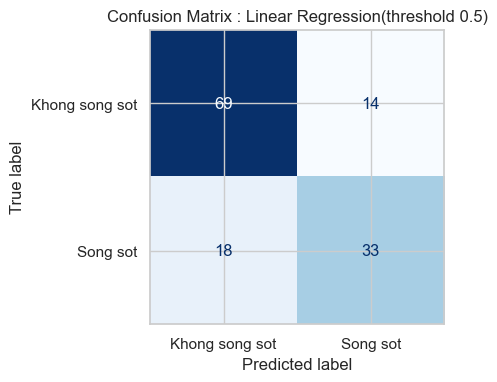

In [8]:
lr_evaluate = evaluate_classification(model_name = "Linear Regression(threshold 0.5)", y_true = y_test, y_pred = y_pred_lr)
results.append(lr_evaluate)

## 6. Logistic Regression

Logistic Regression được thiết kế đúng cho bài toán phân loại: đầu ra luôn nằm trong khoảng
[0, 1] (thông qua hàm sigmoid), biểu diễn **xác suất** sống sót, sau đó mặc định threshold tại
0.5 để ra nhãn 0/1.


In [9]:
# Cập nhật mô hình Logistic Regression
log_model = LogisticRegression(max_iter = 1000, random_state = RANDOM_STATE)
log_model.fit(X_train_t, y_train)      # Cho kết quả là bộ trọng số w và b tối ưu: y = wX + b

y_pred_log = log_model.predict(X_test_t)

# predict_proba trả về xác suất cho từng lớp, luôn nằm trong [0, 1]
y_proba_log = log_model.predict_proba(X_test_t)[:, 1]         # Lấy cột 1: xác suất mẫu thuộc lớp 1

print(f"\nGia tri du doan nho nhat: {y_proba_log.min():.3f}")
print(f"Gia tri du doan lon nhat: {y_proba_log.max():.3f}")


Gia tri du doan nho nhat: 0.011
Gia tri du doan lon nhat: 0.964


Ket qua danh gia: Logistic Regression
Accuracy  : 0.784
Precision : 0.750
Recall    : 0.647
F1-score  : 0.695

Chi tiet:
                   precision    recall  f1-score   support

Khong song sot(0)      0.800     0.867     0.832        83
      Song sot(1)      0.750     0.647     0.695        51

         accuracy                          0.784       134
        macro avg      0.775     0.757     0.764       134
     weighted avg      0.781     0.784     0.780       134



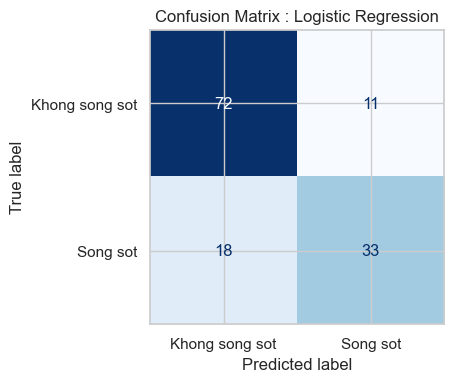

In [10]:
log_result = evaluate_classification(model_name = "Logistic Regression", y_true = y_test, y_pred = y_pred_log)
results.append(log_result)

## 7. So sánh hai mô hình và Nhận xét

In [11]:
comparison_df = pd.DataFrame(results).set_index("model").round(4)
display(comparison_df)

best_model = comparison_df["f1_score"].idxmax()
print(f"\n>>> Mo hinh co F1 cao hon: {best_model}")

,accuracy,precision,recall,f1_score
model,,,,
Linear Regression(threshold 0.5),0.7612,0.7021,0.6471,0.6735
Logistic Regression,0.7836,0.7500,0.6471,0.6947



>>> Mo hinh co F1 cao hon: Logistic Regression


**Nhận xét:**
- Cả hai mô hình dùng chung một tập train/test và có cùng một pipeline tiền xử lý.
- **Logistic Regression phù hợp hơn so với Linear Regression** cho bài toán phân loại nhị phân này:
  + Đầu ra của Logistic Regression là **xác suất** (luôn nằm trong [0, 1]) nhờ hàm sigmoid, trong khi Linear Regression cho ra giá trị không giới hạn (có thể lớn hơn 1 hay nhỏ hơn 0), nên việc diễn giải làm không tường minh và chính xác bằng.
  + Hàm mất mát của Logistic Regression được xây dựng riêng cho phân loại (đặc biệt phân loại nhị phân), trong khi Linear Regression tối ưu theo sai số bình phương (MSE), hình phạt quá nhẹ và không phù hợp về mặt toán học cho bài toán phân loại.
  + Việc phải "threshold tại 0.5 sau khi hồi quy" ở Linear Regression chỉ là một cách chuyển đổi tạm, đoán mò để có thể phân loại, không phải cách tốt, đặc biệt với bộ dữ liệu thực tế.
- Nhìn vào bảng và biểu đồ so sánh chỉ số từ các metric đánh giá, Logistic Regression cho chỉ số bằng hoặc cao hơn Linear Regression, chứng minh sự phụ hợp của Logistic Regression đối với bài toán phân loại.